<img src="images/cads-logo.png" style="height: 100px;" align=left> <img src="images/sklearn-logo.png" style="height: 100px;" align=right>
# Machine Learning

# Day5:  In Depth: Principal Component Analysis

Up until now, we have been looking in depth at supervised learning estimators: those estimators that predict labels based on labeled training data.
Here we begin looking at several unsupervised estimators, which can highlight interesting aspects of the data without reference to any known labels.

In this section, we explore what is perhaps one of the most broadly used of unsupervised algorithms, principal component analysis (PCA).
PCA is fundamentally a dimensionality reduction algorithm, but it can also be useful as a tool for visualization, for noise filtering, for feature extraction and engineering, and much more.
After a brief conceptual discussion of the PCA algorithm, we will see a couple examples of these further applications.

We begin with the standard imports:

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, RobustScaler

Let's have a look at this short video explaining the intuition behind PCA. [A Layman's introduction to PCA](https://www.youtube.com/watch?v=BfTMmoDFXyE)

## Introducing Principal Component Analysis

Principal component analysis is a fast and flexible unsupervised method for dimensionality reduction in data.
Its behavior is easiest to visualize by looking at a two-dimensional dataset.
Consider the following 200 points:

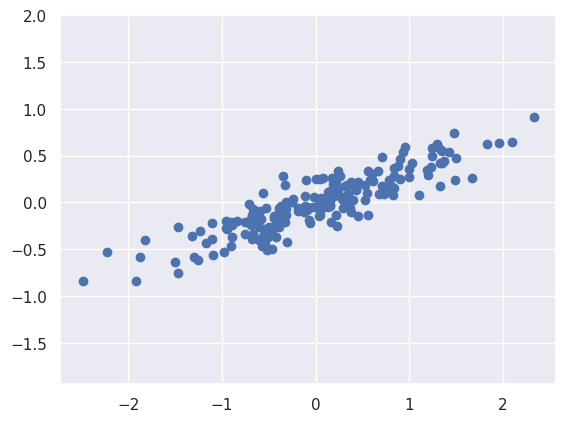

In [2]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');

### Standardize the Data
PCA is effected by scale so you need to scale the features in the data before applying PCA. You can transform the data onto unit scale (mean = 0 and variance = 1) which is a requirement for the optimal performance of many machine learning algorithms. `StandardScaler` helps standardize the dataset’s features.

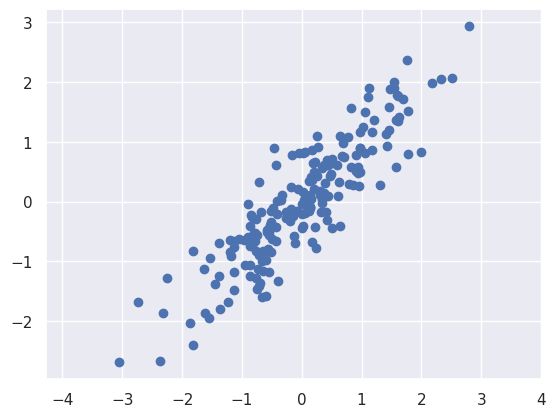

In [3]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)
plt.scatter(X_Scaled[:, 0], X_Scaled[:, 1])
plt.axis('equal');

By eye, it is clear that there is a nearly linear relationship between the x and y variables.
This is reminiscent of the linear regression data we explored in `Linear Regression` session, but the problem setting here is slightly different: rather than attempting to *predict* the y values from the x values, the unsupervised learning problem attempts to learn about the *relationship* between the x and y values.

In principal component analysis, this relationship is quantified by finding a list of the *principal axes* in the data, and using those axes to describe the dataset.
Using Scikit-Learn's ``PCA`` estimator, we can compute this as follows:

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X_Scaled)

PCA(n_components=2)

The fit learns some quantities from the data, most importantly the "components" and "explained variance":

In [5]:
print(pca.components_)

[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [6]:
pca.mean_

array([-3.10862447e-17,  0.00000000e+00])

#### explained variance
The explained variance tells you how much information (variance) can be attributed to each of the principal components. This is important as while you can convert 4 dimensional space to 2 dimensional space, you lose some of the variance (information) when you do this.

In [7]:
print(pca.explained_variance_)

[1.89888438 0.11116588]


To see what these numbers mean, let's visualize them as vectors over the input data, using the "components" to define the direction of the vector, and the "explained variance" to define the squared-length of the vector:

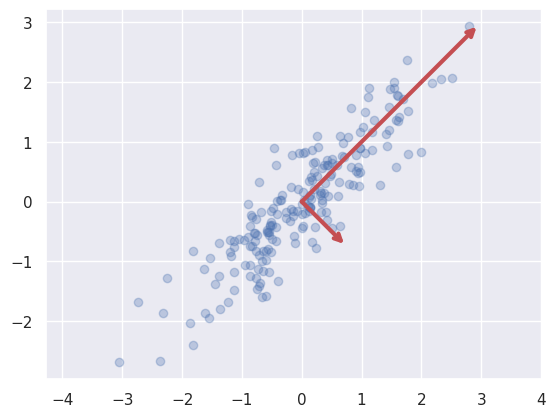

In [8]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=3,
                    shrinkA=0, shrinkB=0, color='r')
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X_Scaled[:, 0], X_Scaled[:, 1], alpha=0.3)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector* np.sqrt(length)*3
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

These vectors represent the *principal axes* of the data, and the length of the vector is an indication of how "important" that axis is in describing the distribution of the data—more precisely, it is a measure of the variance of the data when projected onto that axis.
The projection of each data point onto the principal axes are the "principal components" of the data.

If we plot these principal components beside the original data, we see the plots shown here:

![](images/05.09-PCA-rotation.png)
[figure source in Appendix](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Principal-Components-Rotation)

While this algorithm to find principal components may seem like just a mathematical curiosity, it turns out to have very far-reaching applications in the world of machine learning and data exploration.

### PCA as dimensionality reduction

Using PCA for dimensionality reduction involves zeroing out one or more of the smallest principal components, resulting in a lower-dimensional projection of the data that preserves the maximal data variance.

Here is an example of using PCA as a dimensionality reduction transform:

In [9]:
pca = PCA(n_components=1)
pca.fit(X_Scaled)
X_pca = pca.transform(X_Scaled)
print("original shape:   ", X_Scaled.shape)
print("transformed shape:", X_pca.shape)

original shape:    (200, 2)
transformed shape: (200, 1)


The transformed data has been reduced to a single dimension.
To understand the effect of this dimensionality reduction, we can perform the inverse transform of this reduced data and plot it along with the original data:

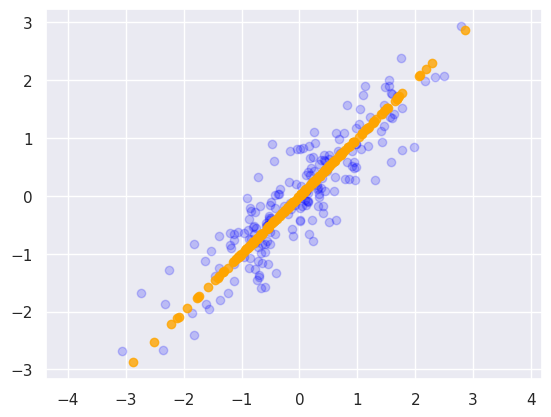

In [10]:
X_new = pca.inverse_transform(X_pca)
plt.scatter(X_Scaled[:, 0], X_Scaled[:, 1], alpha=0.2, c='blue')
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8, c='orange')
plt.axis('equal');

The blue points are the original data, while the orange points are the projected version.
This makes clear what a PCA dimensionality reduction means: the information along the least important principal axis or axes is removed, leaving only the component(s) of the data with the highest variance.

The fraction of variance that is cut out (proportional to the spread of points about the line formed in this figure) is roughly a measure of how much "information" is discarded in this reduction of dimensionality.

This reduced-dimension dataset is in some senses "good enough" to encode the most important relationships between the points: despite reducing the dimension of the data by 50%, the overall relationship between the data points are mostly preserved.

### Visualizing high-dimensional data

One of the most common applications of PCA is visualizing high-dimensional datasets. The following code tries to visualize the cancer dataset.

In [11]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer.data[:3,:]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
        1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
        4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
        2.250e-02, 4.571e-03, 2.357e

In [12]:
cancer.data.shape

(569, 30)

As this dataset has 30 features, we can draw scatterplots of all two by two features or histogram of each feature. But the number of two by two combinations of 30 features will result in 435 plots! We would never be able to look at these plots in detail, let alone try understanding and analyzing them.

One way to visualize the separation between the classes is by computing histograms of each of the features for the two classes -- benign and malignant cancer. This is a simple way to see which features are likely to be able to separate the two classes well.

Here we create a histogram for each of the features. Each histogram counts how often a data point appears with a feature in a certain range (called a *bin*). Each plot overlays two histograms, one for all the points in the benign class (green) and one for all the points in the malignant class (blue). This gives us some idea of how each feature is distributed across the two classes and allows us to make a guess as to which features are better at distinguishing malignant and benign samples. For example, "smoothness error" seems quite uninformative while the feature "worst concave points" seems quite useful because we can tell apart the two classes with little overlap between them.

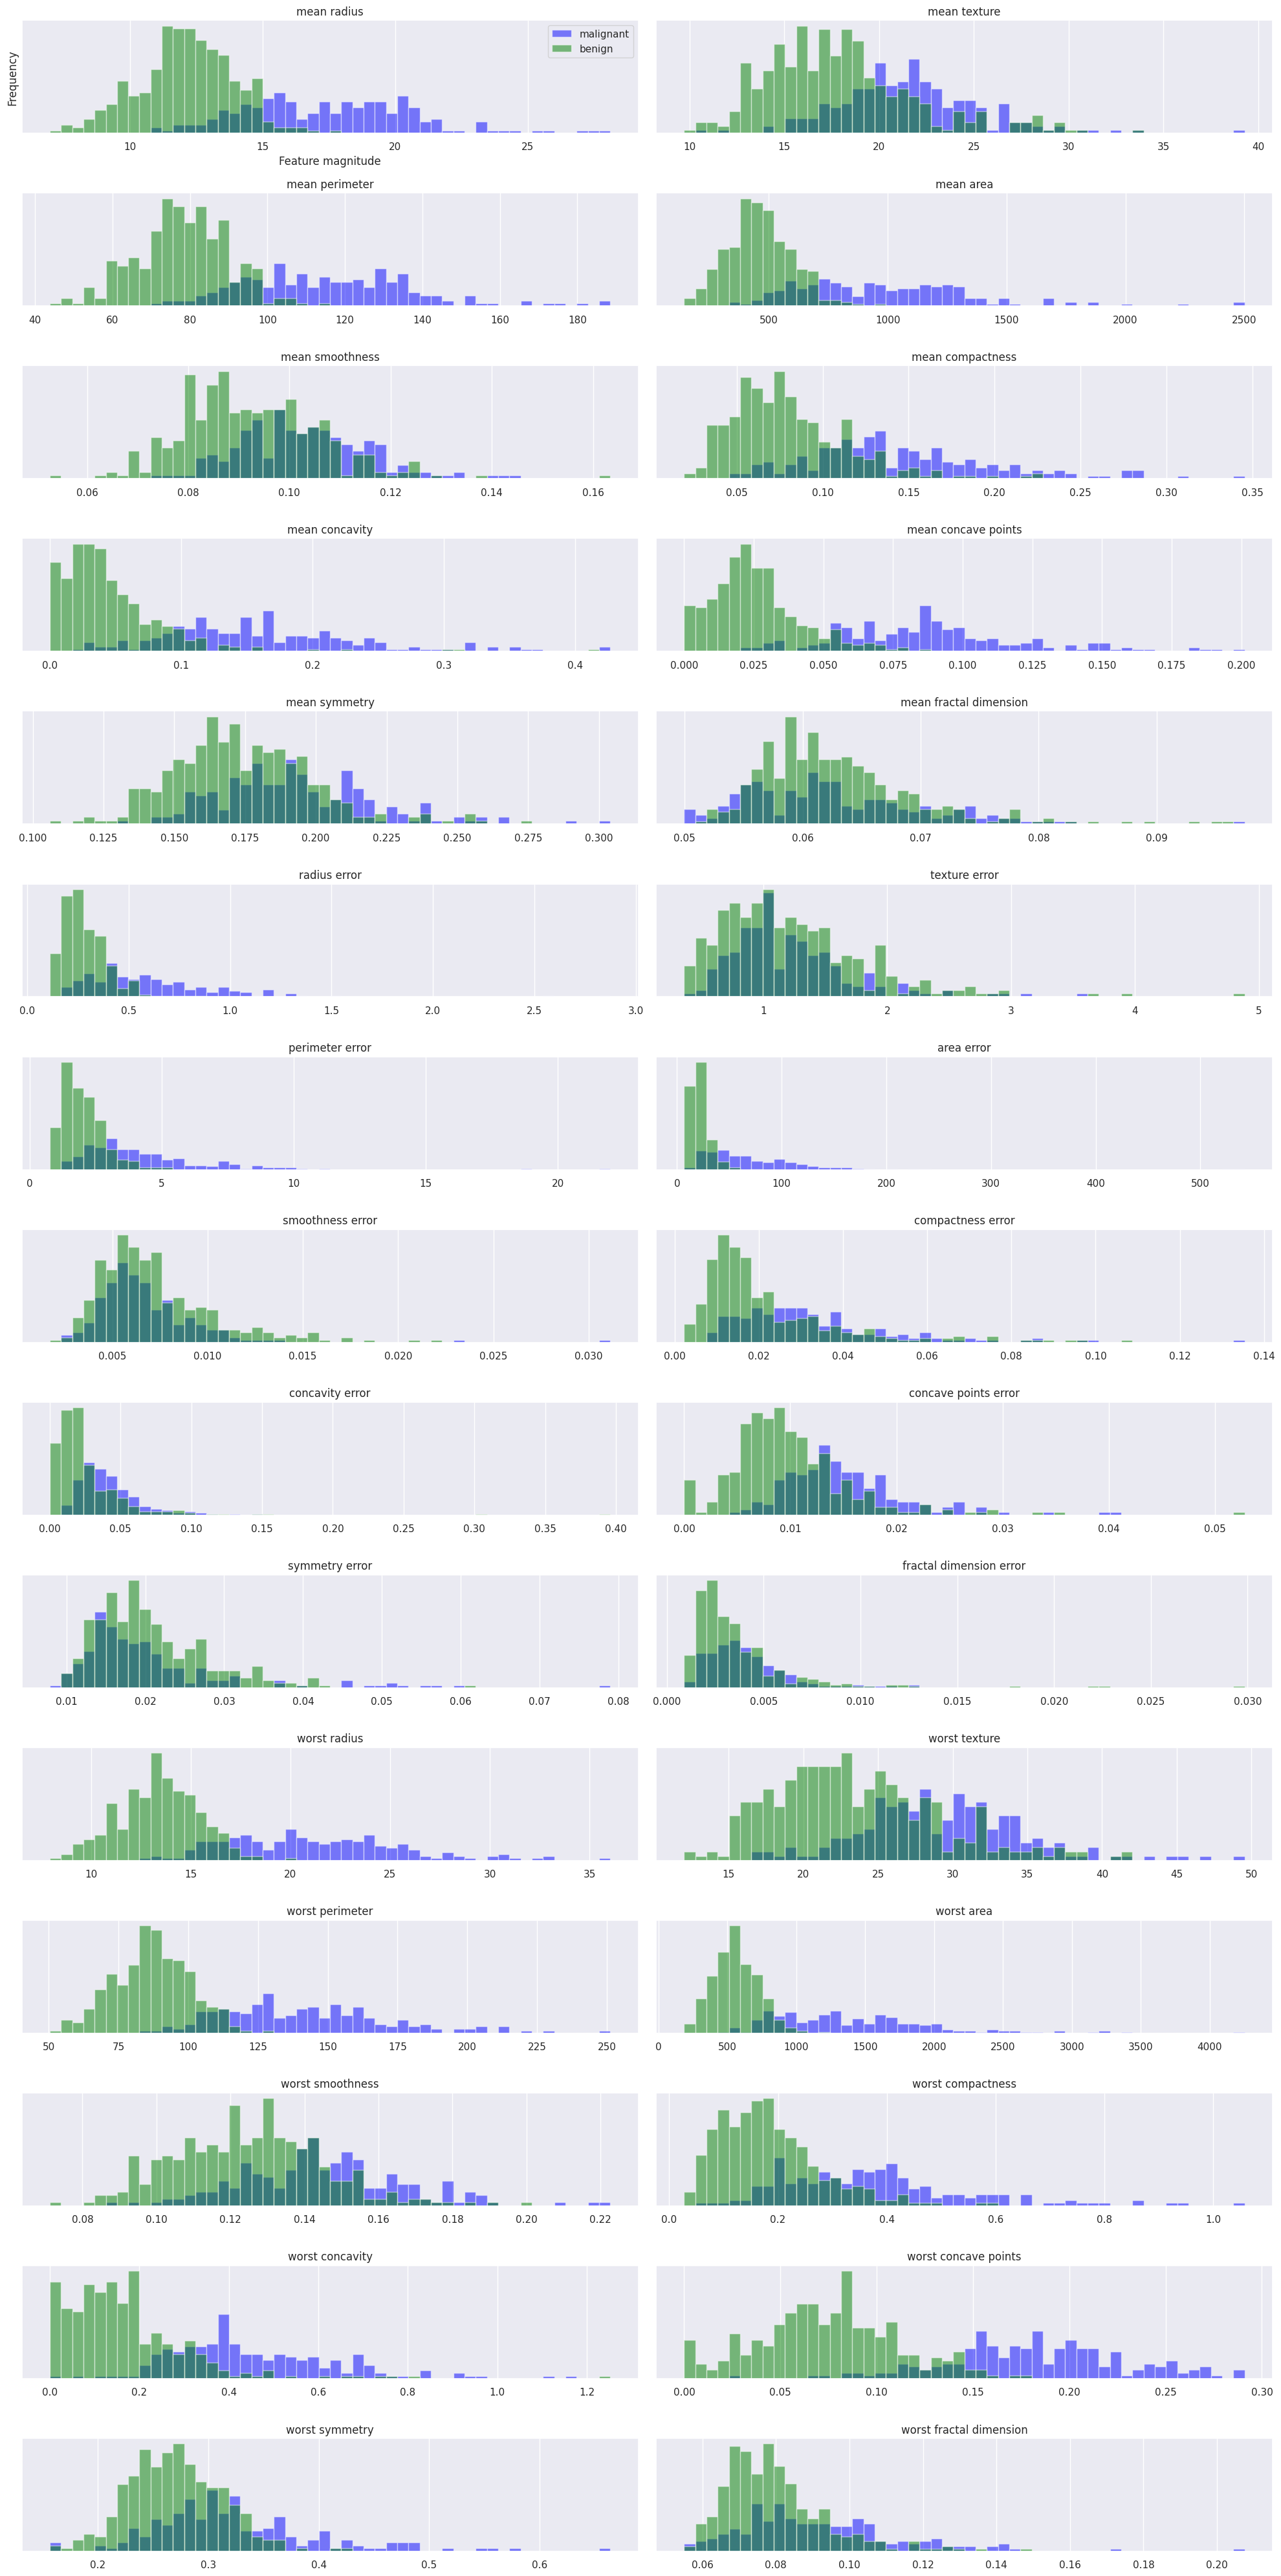

In [13]:
fig, axes = plt.subplots(15, 2, figsize=(20, 40))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]
ax = axes.ravel()
for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color='blue', alpha=.5)
    ax[i].hist(benign[:, i], bins=bins, color='green', alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())

ax[0].set_xlabel("Feature magnitude")
ax[0].set_ylabel("Frequency")
ax[0].legend(["malignant", "benign"], loc="best")
fig.tight_layout()
plt.show()

By using PCA, we can capture the main interactions between these variables and get a more complete picture. We can find the first two principal components (at least visually possible) and visualize the data in this new two-dimensional space with a single scatter plot. Before we apply PCA, let's also scale our data with `StandardScaler` so that each feature has unit variance:

In [14]:
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

Learning the PCA transformation and applying it is as simple as applying a preprocessing transformation. We instantiate the `PCA` object, find the principal components by calling the `fit()` method, and then apply the rotation and dimensionality reduction by calling `transform()`. (You can call both together thru `fit_transform()`.)

As usual PCA rotates (and shifts) the data, but keeps all principal components. To reduce the dimensionality of the data, we need to specify how many components we want to keep when creating the PCA object:

In [22]:
X_scaled.shape

(569, 30)

In [23]:
# keep the first two principal components of the data
pca = PCA(n_components=2)

# fit PCA model to breast cancer data
pca.fit(X_scaled)

# transform data onto the first two principal components
X_pca = pca.transform(X_scaled)
print("Original shape: {}".format(str(X_scaled.shape)))
print("Reduced shape: {}".format(str(X_pca.shape)))

Original shape: (569, 30)
Reduced shape: (569, 2)


In [24]:
print(pca.components_)

[[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


In [25]:
print(pca.mean_)
print(pca.mean_.shape)

[-3.16286735e-15 -6.53060890e-15 -7.07889127e-16 -8.79983452e-16
  6.13217737e-15 -1.12036918e-15 -4.42138027e-16  9.73249991e-16
 -1.97167024e-15 -1.45363120e-15 -9.07641468e-16 -8.85349205e-16
  1.77367396e-15 -8.29155139e-16 -7.54180940e-16 -3.92187747e-16
  7.91789988e-16 -2.73946068e-16 -3.10823423e-16 -3.36676596e-16
 -2.33322442e-15  1.76367415e-15 -1.19802625e-15  5.04966114e-16
 -5.21317026e-15 -2.17478837e-15  6.85645643e-16 -1.41265636e-16
 -2.28956670e-15  2.57517109e-15]
(30,)


In [26]:
print(X_pca.shape)
X_pca

(569, 2)


array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

You can now plot the first two principal components:

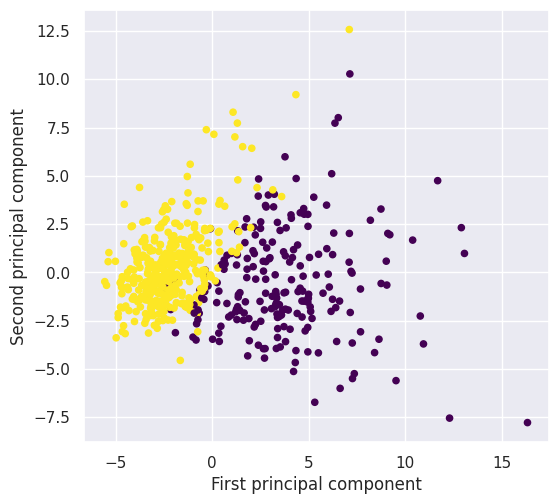

In [27]:
# plot first vs. second principal component, colored by class
plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cancer.target, cmap='viridis', s=20)
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.show()

### Uploading Data from Your Local Machine

To upload a file from your local computer, you can use the `files.upload` function from `google.colab`. When you run the following cell, a button will appear that allows you to select and upload files from your local system. The uploaded files will then be available in the Colab environment.

In [28]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving iris.csv to iris (1).csv
User uploaded file "iris (1).csv" with length 3716 bytes


After uploading, you can use pandas (or other libraries) to read your data. For example, if you uploaded a CSV file named `my_data.csv`, you can read it like this:

```python
import pandas as pd
df = pd.read_csv('my_data.csv')
display(df.head())
```

In [29]:
import pandas as pd
df = pd.read_csv('iris.csv')
display(df.head())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
from sklearn.datasets import load_iris
iris = load_iris()
iris.data[:3,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [31]:
iris.data.shape

(150, 4)

Original shape: (150, 4)
Reduced shape: (150, 2)


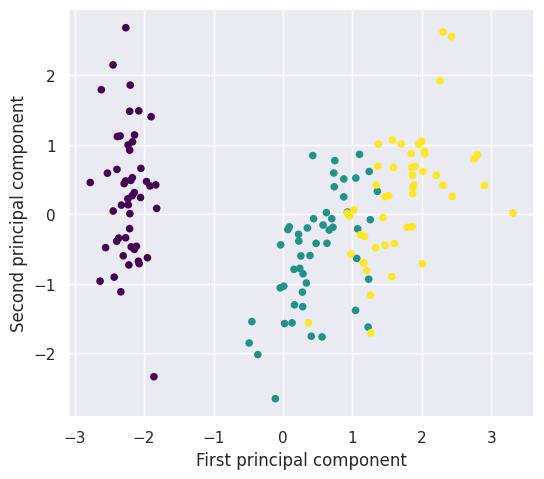

In [32]:
iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

print("Original shape: {}".format(str(X_scaled.shape)))
print("Reduced shape: {}".format(str(X_pca.shape)))

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=20)
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.show()

In [37]:
pca.explained_variance_

array([2.93808505, 0.9201649 ])

In [39]:
pca_explained_variance_ratio = pca.explained_variance_ratio_
pca_explained_variance_ratio

array([0.72962445, 0.22850762])

It is important to note that PCA is an unsupervised method, and does not use any class information when finding the rotation. It simply looks at the correlations in the data. For the scatter plot shown here, we plotted the first principal component against the second principal component, and then used the class information to color the points (class information was never used to learn this distribution). You can see that the two classes separate quite well in this 2-D space. This leads us to believe that even a linear classifier (that would learn a line in this space) could do a reasonably good job at distinguishing the two classes. We can also see that the malignant (purple) points are more spread out than the benign (yellow) points, something that we could already see a bit from the histograms earlier.

A downside of PCA is that the two axes in the plot are often not very easy to interpret. The principal components correspond to directions in the original data, so they are *combinations of the original features*. However, these combinations are usually very complex.

### Dissecting PCA

Let's take a look at what makes this PCA work.

In [40]:
print("PCA component shape: {}".format(pca.components_.shape))

PCA component shape: (2, 4)


Each row in `components_` corresponds to one principal component, and they are sorted by their importance (the first principal component comes first, and etc.). The columns correspond to the original features attribute of the PCA in this example, "mean
radius", "mean texture", and so on. Recall, there were 30 of them. Let's have a look at the content of `components_`:

In [41]:
print("PCA components:\n{}".format(pca.components_))

PCA components:
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


We can also visualize the coefficients using a heatmap, which might be easier to understand:

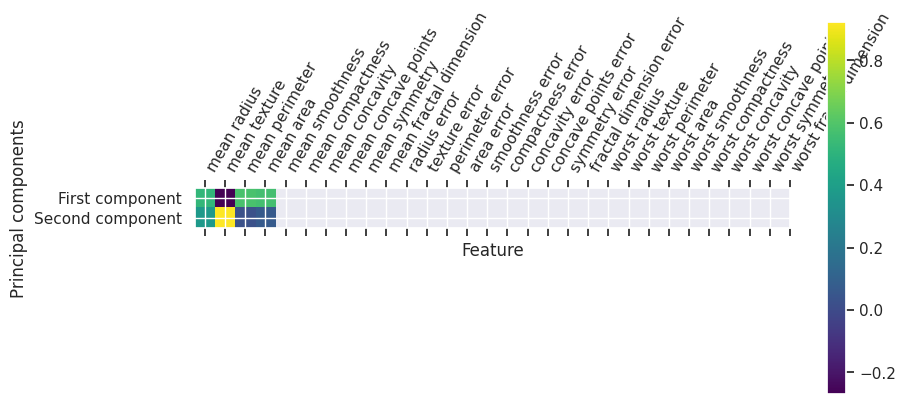

In [42]:
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")
plt.show()

In [43]:
pca.explained_variance_

array([2.93808505, 0.9201649 ])

You can see that in the first component, all features have the same sign (all positive, but it actually doesn't matter which direction). That means that there is a general correlation between all features. As one measurement is high, the others are likely to be high as well. The second component has mixed signs, and both of the components involve all of the 30 features. This mixing of features is what makes explaining the earlier axes tricky.

### PCA for visualization: Hand-written digits

The usefulness of the dimensionality reduction may not be entirely apparent in only two dimensions, but becomes much more clear when looking at high-dimensional data.
To see this, let's take a quick look at the application of PCA to the digits data we saw in [ML13 Decision Trees and Random Forests](ML13_Decision_Tree_Random_Forests.ipynb).

We start by loading the data:

In [44]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

Recall that the data consists of 8×8 pixel images, meaning that they are 64-dimensional.
To gain some intuition into the relationships between these points, we can use PCA to project them to a more manageable number of dimensions, say two:

In [45]:
pca = PCA(2)  # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


We can now plot the first two principal components of each point to learn about the data:

/tmp/ipykernel_3428/1119964495.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('nipy_spectral', 10))


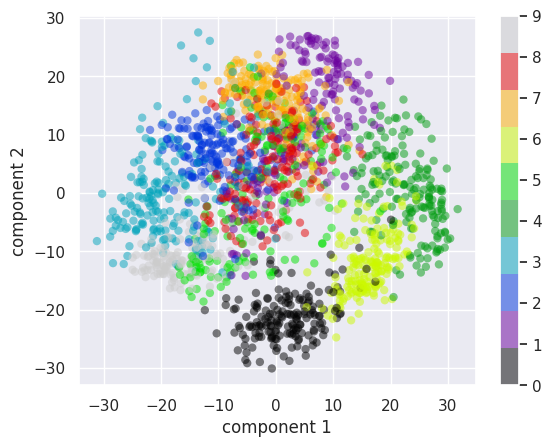

In [46]:
plt.scatter(projected[:, 0], projected[:, 1],
            c=digits.target, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('nipy_spectral', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

Recall what these components mean: the full data is a 64-dimensional point cloud, and these points are the projection of each data point along the directions with the largest variance.
Essentially, we have found the optimal stretch and rotation in 64-dimensional space that allows us to see the layout of the digits in two dimensions, and have done this in an unsupervised manner—that is, without reference to the labels.

### What do the components mean?

We can go a bit further here, and begin to ask what the reduced dimensions *mean*.
This meaning can be understood in terms of combinations of basis vectors.
For example, each image in the training set is defined by a collection of 64 pixel values, which we will call the vector $x$:

$$
x = [x_1, x_2, x_3 \cdots x_{64}]
$$

One way we can think about this is in terms of a pixel basis.
That is, to construct the image, we multiply each element of the vector by the pixel it describes, and then add the results together to build the image:

$$
{\rm image}(x) = x_1 \cdot{\rm (pixel~1)} + x_2 \cdot{\rm (pixel~2)} + x_3 \cdot{\rm (pixel~3)} \cdots x_{64} \cdot{\rm (pixel~64)}
$$

One way we might imagine reducing the dimension of this data is to zero out all but a few of these basis vectors.
For example, if we use only the first eight pixels, we get an eight-dimensional projection of the data, but it is not very reflective of the whole image: we've thrown out nearly 90% of the pixels!

![](images/05.09-digits-pixel-components.png)


The upper row of panels shows the individual pixels, and the lower row shows the cumulative contribution of these pixels to the construction of the image.
Using only eight of the pixel-basis components, we can only construct a small portion of the 64-pixel image.
Were we to continue this sequence and use all 64 pixels, we would recover the original image.

But the pixel-wise representation is not the only choice of basis. We can also use other basis functions, which each contain some pre-defined contribution from each pixel, and write something like

$$
image(x) = {\rm mean} + x_1^{\prime} \cdot{\rm (basis~1)} + x_2^{\prime} \cdot{\rm (basis~2)} + x_3^{\prime} \cdot{\rm (basis~3)} \cdots + x_8^{\prime} \cdot{\rm (basis~8)}
$$

PCA can be thought of as a process of choosing optimal basis functions, such that adding together just the first few of them is enough to suitably reconstruct the bulk of the elements in the dataset.
The principal components, which act as the low-dimensional representation of our data, are simply the coefficients that multiply each of the elements in this series.
This figure shows a similar depiction of reconstructing this digit using the mean plus the first eight PCA basis functions:

![](images/05.09-digits-pca-components.png)


Unlike the pixel basis, the PCA basis allows us to recover the salient features of the input image with just a mean plus eight components!
The amount of each pixel in each component is the corollary of the orientation of the vector in our two-dimensional example.
This is the sense in which PCA provides a low-dimensional representation of the data: it discovers a set of basis functions that are more efficient than the native pixel-basis of the input data.

### Choosing the number of components

A vital part of using PCA in practice is the ability to estimate how many components are needed to describe the data.
This can be determined by looking at the cumulative *explained variance ratio* as a function of the number of components:

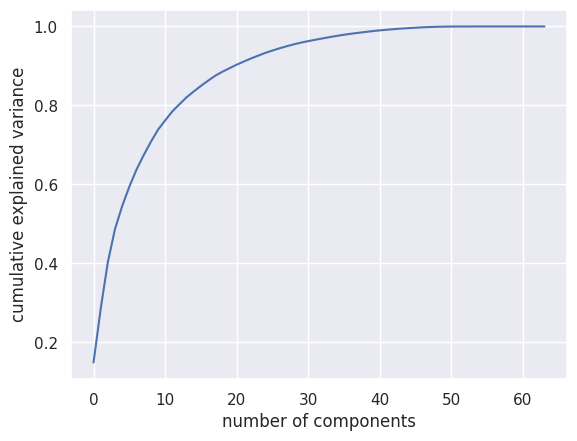

In [47]:
pca = PCA().fit(digits.data)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

This curve quantifies how much of the total, 64-dimensional variance is contained within the first $N$ components.
For example, we see that with the digits the first 10 components contain approximately 75% of the variance, while you need around 50 components to describe close to 100% of the variance.

Here we see that our two-dimensional projection loses a lot of information (as measured by the explained variance) and that we'd need about 20 components to retain 90% of the variance.  Looking at this plot for a high-dimensional dataset can help you understand the level of redundancy present in multiple observations.

## PCA as Noise Filtering

PCA can also be used as a filtering approach for noisy data.
The idea is this: any components with variance much larger than the effect of the noise should be relatively unaffected by the noise.
So if you reconstruct the data using just the largest subset of principal components, you should be preferentially keeping the signal and throwing out the noise.

Let's see how this looks with the digits data.
First we will plot several of the input noise-free data:

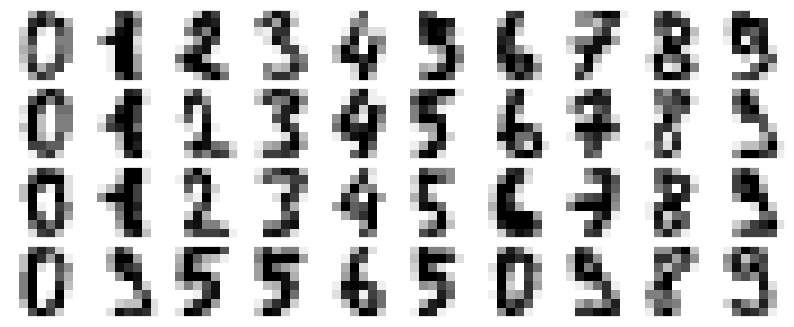

In [48]:
def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(10, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))
plot_digits(digits.data)

Now lets add some random noise to create a noisy dataset, and re-plot it:

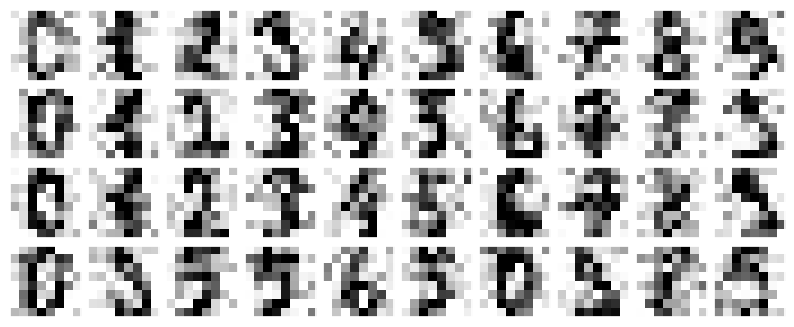

In [49]:
np.random.seed(42)
noisy = np.random.normal(digits.data, scale=4)
plot_digits(noisy)

It's clear by eye that the images are noisy, and contain spurious pixels.
Let's train a PCA on the noisy data, requesting that the projection preserve 50% of the variance:

In [50]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

np.int64(12)

Here 50% of the variance amounts to 12 principal components.
Now we compute these components, and then use the inverse of the transform to reconstruct the filtered digits:

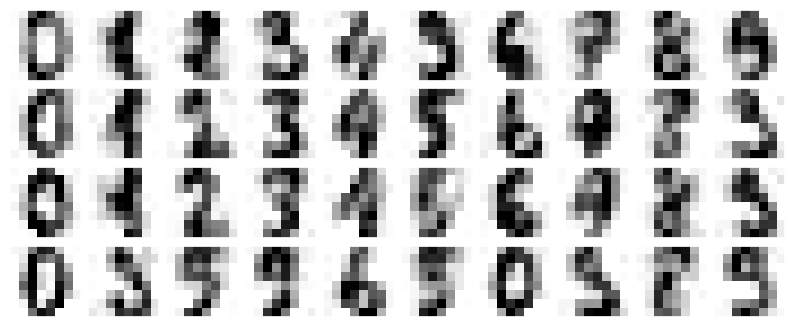

In [51]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)

This signal preserving/noise filtering property makes PCA a very useful feature selection routine—for example, rather than training a classifier on very high-dimensional data, you might instead train the classifier on the lower-dimensional representation, which will automatically serve to filter out random noise in the inputs.

## Example: Eigenfaces



 We will use the Labeled Faces in the Wild dataset, which consists of several thousand collated photos of various public figures. A fetcher for the dataset is built into Scikit-Learn:

In [52]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Let's plot a few of these faces to see what we're working with:

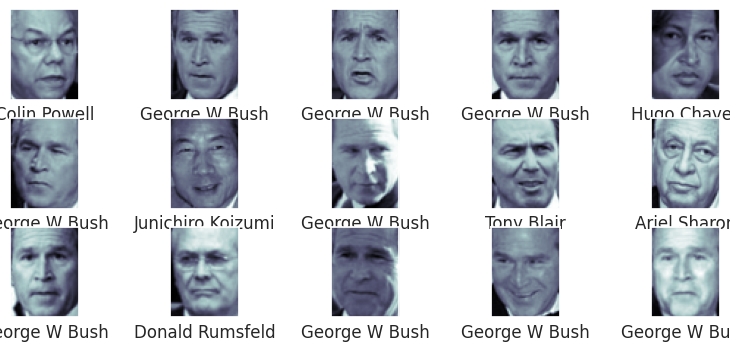

In [53]:
fig, ax = plt.subplots(3, 5, figsize=(10, 4))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

Let's take a look at the principal axes that span this dataset.
Because this is a large dataset, we will use ``RandomizedPCA``—it contains a randomized method to approximate the first $N$ principal components much more quickly than the standard ``PCA`` estimator, and thus is very useful for high-dimensional data (here, a dimensionality of nearly 3,000).
We will take a look at the first 150 components:

In [58]:
# pca without scaling
from sklearn.decomposition import PCA

pca = PCA(150, svd_solver='randomized').fit(faces.data)     # just select 150 features

In [59]:
# pca with scaling
from sklearn.decomposition import PCA
scaler = StandardScaler()
faces.data_scaled=scaler.fit_transform(faces.data)
pca_scaled = PCA(150, svd_solver='randomized').fit(faces.data_scaled)

In this case, it can be interesting to visualize the images associated with the first several principal components (these components are technically known as "eigenvectors,"
so these types of images are often called "eigenfaces").
As you can see in this figure, they are as creepy as they sound:

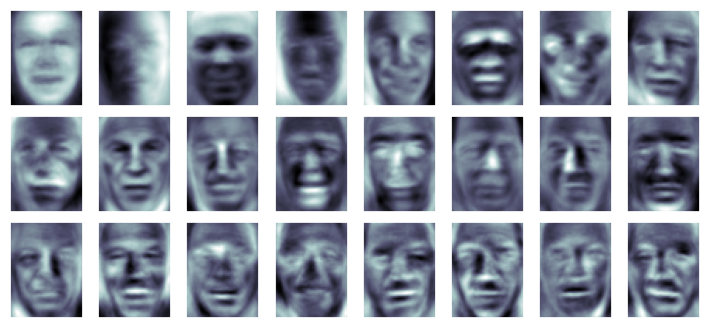

In [60]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca_scaled.components_[i].reshape(62, 47), cmap='bone')

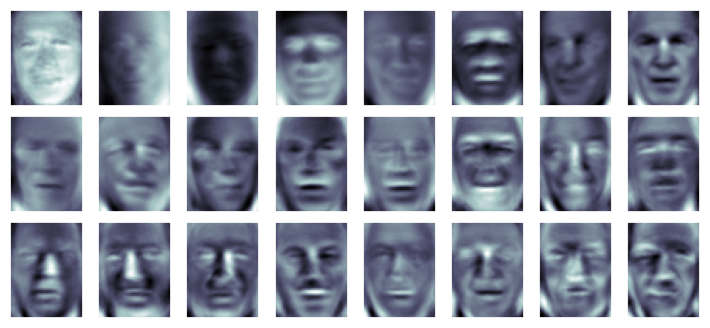

In [61]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(62, 47), cmap='bone')

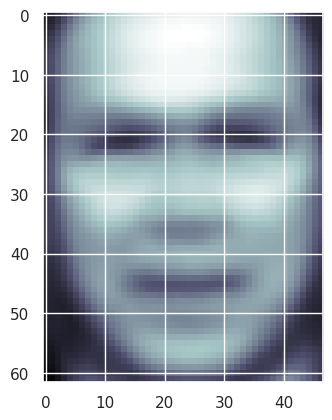

In [63]:
# Make and plot a new face by selecting some components and useing your own coefficients

# Reconstruct a face using the mean and the first principal component
# Adjust the coefficient (e.g., 5) to see different variations
new_face = pca.mean_.reshape(62, 47) + 5 * pca.components_[0].reshape(62, 47)
plt.imshow(new_face, cmap='bone')

The results are very interesting, and give us insight into how the images vary: for example, the first few eigenfaces (from the top left) seem to be associated with the angle of lighting on the face, and later principal vectors seem to be picking out certain features, such as eyes, noses, and lips.
Let's take a look at the cumulative variance of these components to see how much of the data information the projection is preserving:

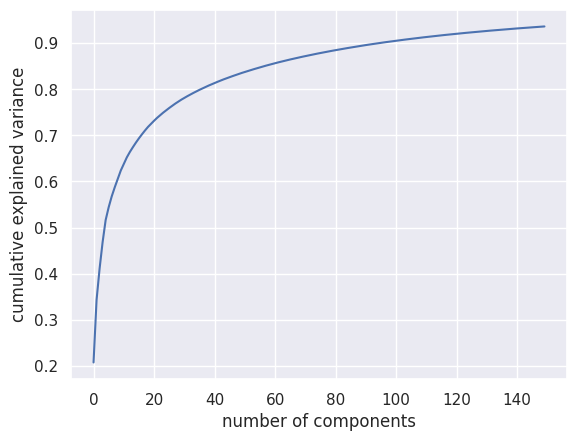

In [64]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

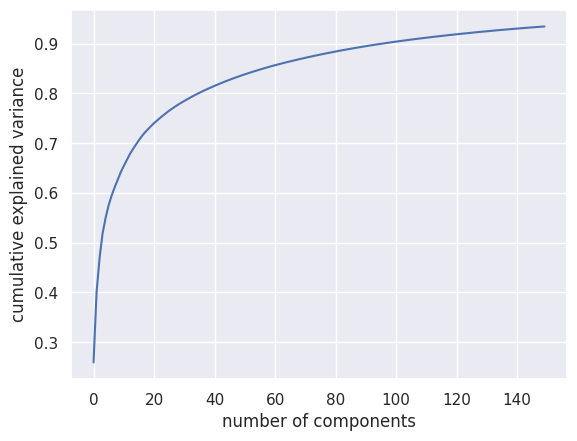

In [65]:
plt.plot(np.cumsum(pca_scaled.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

We see that these 150 components account for just over 90% of the variance.
That would lead us to believe that using these 150 components, we would recover most of the essential characteristics of the data.
To make this more concrete, we can compare the input images with the images reconstructed from these 150 components:

In [66]:
# Compute the components and projected faces
pca = PCA(150, svd_solver='randomized').fit(faces.data)
components = pca.transform(faces.data)
projected = pca.inverse_transform(components)

In [ ]:
# Plot the results
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')

ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('150-dim\nreconstruction');

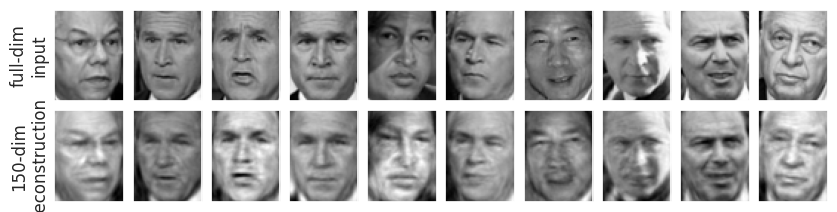

In [67]:
pca_scaled = PCA(150, svd_solver='randomized').fit(faces.data_scaled)
components_scaled = pca_scaled.transform(faces.data)
projected_scaled = pca_scaled.inverse_transform(components_scaled)

# Plot the results
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected_scaled[i].reshape(62, 47), cmap='binary_r')

ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('150-dim\nreconstruction');

### Exercise:

Change the above plot so that we can see three rows of faces: input, transformed with PCA without scaling, and with scaling.

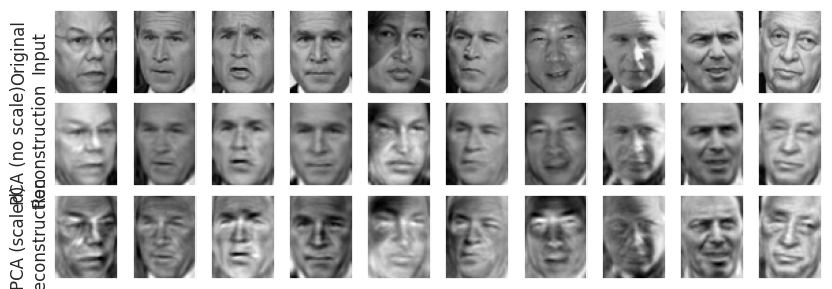

In [69]:
# Recompute components and projected faces for both scaled and unscaled data if not already done
# pca without scaling
pca_unscaled = PCA(150, svd_solver='randomized').fit(faces.data)
components_unscaled = pca_unscaled.transform(faces.data)
projected_unscaled = pca_unscaled.inverse_transform(components_unscaled)

# pca with scaling
pca_scaled_recompute = PCA(150, svd_solver='randomized').fit(faces.data_scaled)
components_scaled_recompute = pca_scaled_recompute.transform(faces.data_scaled)
projected_scaled_recompute = pca_scaled_recompute.inverse_transform(components_scaled_recompute)

# Plot the results
fig, ax = plt.subplots(3, 10, figsize=(10, 3.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i in range(10):
    # Original Input
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    # PCA without scaling reconstruction
    ax[1, i].imshow(projected_unscaled[i].reshape(62, 47), cmap='binary_r')
    # PCA with scaling reconstruction
    ax[2, i].imshow(projected_scaled_recompute[i].reshape(62, 47), cmap='binary_r')

ax[0, 0].set_ylabel('Original\nInput')
ax[1, 0].set_ylabel('PCA (no scale)\nReconstruction')
ax[2, 0].set_ylabel('PCA (scaled)\nReconstruction');

Great! The code has executed successfully, and I've generated the plot comparing the original faces, PCA reconstructions without scaling, and PCA reconstructions with scaling. The figure shows three rows:

- Original Input: The top row displays the original facial images.
- PCA (no scale) Reconstruction: The middle row shows the faces reconstructed after applying PCA without prior data scaling.
- PCA (scaled) Reconstruction: The bottom row presents the faces reconstructed after applying PCA to scaled data.

This plot allows for a visual comparison of how scaling affects the quality of the reconstructed images when using PCA for dimensionality reduction.

The top row here shows the input images, while the bottom row shows the reconstruction of the images from just 150 of the ~3,000 initial features.

With this visualization we can guess that the PCA feature selection would be successful for image classification: although it reduces the dimensionality of the data by nearly a factor of 20, the projected images contain enough information that we might, by eye, recognize the individuals in the image.
What this means is that our classification algorithm needs to be trained on 150-dimensional data rather than 3,000-dimensional data, which depending on the particular algorithm we choose, can lead to a much more efficient classification.

### Exercise

- Train SVM with linear kernel, LogisticRegression, KNN, Naibe Bayes and Decision tree classifiers on this dataset. With and without dimensionality reduction.
- What is the accuracy obtained on the test set?
- Show the classification report
- Show the confusion matrix

In [73]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=42)

### Classifiers without Dimensionality Reduction (PCA)

In [74]:
# Import necessary libraries for classification
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [75]:
# Logistic Regression
print("--- Logistic Regression (without PCA) ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(Xtrain, ytrain)
y_pred_log_reg = log_reg.predict(Xtest)

print(f"Accuracy: {accuracy_score(ytest, y_pred_log_reg):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_log_reg))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_log_reg))

--- Logistic Regression (without PCA) ---
Accuracy: 0.9733

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.97      0.97      0.97        37
           2       0.97      0.97      0.97        38
           3       0.96      0.96      0.96        46
           4       1.00      0.98      0.99        55
           5       0.95      0.97      0.96        59
           6       0.98      0.98      0.98        45
           7       1.00      0.98      0.99        41
           8       0.95      0.97      0.96        38
           9       0.96      0.96      0.96        48

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


Confusion Matrix:
 [[43  0  0  0  0  0  0  0  0  0]
 [ 0 36  1  0  0  0  0  0  0  0]
 [ 0  0 37  1  0  0  0  0  0  0]
 [ 0  0  0 44  0  1  0  0  1  0]
 [ 0 

In [76]:
# Support Vector Machine (SVM) with Linear Kernel
print("\n--- SVM (Linear Kernel, without PCA) ---")
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(Xtrain, ytrain)
y_pred_svm_linear = svm_linear.predict(Xtest)

print(f"Accuracy: {accuracy_score(ytest, y_pred_svm_linear):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_svm_linear))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_svm_linear))


--- SVM (Linear Kernel, without PCA) ---
Accuracy: 0.9822

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.97      1.00      0.99        37
           2       0.97      1.00      0.99        38
           3       0.98      0.93      0.96        46
           4       1.00      0.98      0.99        55
           5       0.97      1.00      0.98        59
           6       1.00      1.00      1.00        45
           7       0.98      0.98      0.98        41
           8       1.00      0.97      0.99        38
           9       0.96      0.96      0.96        48

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450


Confusion Matrix:
 [[43  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0]
 [ 0  0  1 43  0  1  0  0  0  1]
 [ 0 

In [77]:
# K-Nearest Neighbors (KNN)
print("\n--- KNN (without PCA) ---")
knn = KNeighborsClassifier(n_neighbors=5) # Using default 5 neighbors
knn.fit(Xtrain, ytrain)
y_pred_knn = knn.predict(Xtest)

print(f"Accuracy: {accuracy_score(ytest, y_pred_knn):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_knn))


--- KNN (without PCA) ---
Accuracy: 0.9933

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        46
           4       0.98      1.00      0.99        55
           5       0.98      0.98      0.98        59
           6       1.00      1.00      1.00        45
           7       1.00      1.00      1.00        41
           8       1.00      1.00      1.00        38
           9       0.98      0.96      0.97        48

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450


Confusion Matrix:
 [[43  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0]
 [ 0  0  0 46  0  0  0  0  0  0]
 [ 0  0  0  0 55  0 

In [78]:
# Gaussian Naive Bayes
print("\n--- Gaussian Naive Bayes (without PCA) ---")
gnb = GaussianNB()
gnb.fit(Xtrain, ytrain)
y_pred_gnb = gnb.predict(Xtest)

print(f"Accuracy: {accuracy_score(ytest, y_pred_gnb):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_gnb))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_gnb))


--- Gaussian Naive Bayes (without PCA) ---
Accuracy: 0.8556

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.85      0.78      0.82        37
           2       0.85      0.61      0.71        38
           3       0.97      0.83      0.89        46
           4       0.98      0.84      0.90        55
           5       0.90      0.95      0.93        59
           6       0.90      0.96      0.92        45
           7       0.71      0.98      0.82        41
           8       0.60      0.89      0.72        38
           9       0.90      0.73      0.80        48

    accuracy                           0.86       450
   macro avg       0.87      0.85      0.85       450
weighted avg       0.88      0.86      0.86       450


Confusion Matrix:
 [[41  0  0  0  0  1  0  1  0  0]
 [ 0 29  2  0  0  0  0  0  4  2]
 [ 0  2 23  0  0  0  1  0 12  0]
 [ 0  0  1 38  0  1  0  0  5  1]
 [ 

In [79]:
# Decision Tree Classifier
print("\n--- Decision Tree (without PCA) ---")
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(Xtrain, ytrain)
y_pred_dec_tree = dec_tree.predict(Xtest)

print(f"Accuracy: {accuracy_score(ytest, y_pred_dec_tree):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_dec_tree))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_dec_tree))


--- Decision Tree (without PCA) ---
Accuracy: 0.8578

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.84      0.86      0.85        37
           2       0.89      0.84      0.86        38
           3       0.79      0.83      0.81        46
           4       0.91      0.89      0.90        55
           5       0.89      0.81      0.85        59
           6       0.93      0.96      0.95        45
           7       0.88      0.88      0.88        41
           8       0.69      0.71      0.70        38
           9       0.81      0.88      0.84        48

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450


Confusion Matrix:
 [[39  0  0  0  3  1  0  0  0  0]
 [ 0 32  1  1  0  0  0  0  3  0]
 [ 0  1 32  3  0  1  0  0  1  0]
 [ 0  0  0 38  0  1  0  1  3  3]
 [ 0  1  0

### Classifiers with Dimensionality Reduction (PCA)

In [80]:
# Apply PCA for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale the data first, as PCA is sensitive to scale
scaler_pca = StandardScaler()
Xtrain_scaled = scaler_pca.fit_transform(Xtrain)
Xtest_scaled = scaler_pca.transform(Xtest)

# Apply PCA, retaining 90% of variance
pca_digits = PCA(n_components=0.90, random_state=42)
Xtrain_pca = pca_digits.fit_transform(Xtrain_scaled)
Xtest_pca = pca_digits.transform(Xtest_scaled)

print(f"Original number of features: {Xtrain.shape[1]}")
print(f"Number of features after PCA (retaining 90% variance): {Xtrain_pca.shape[1]}")

Original number of features: 64
Number of features after PCA (retaining 90% variance): 31


In [81]:
# Logistic Regression with PCA
print("\n--- Logistic Regression (with PCA) ---")
log_reg_pca = LogisticRegression(max_iter=1000, random_state=42)
log_reg_pca.fit(Xtrain_pca, ytrain)
y_pred_log_reg_pca = log_reg_pca.predict(Xtest_pca)

print(f"Accuracy: {accuracy_score(ytest, y_pred_log_reg_pca):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_log_reg_pca))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_log_reg_pca))


--- Logistic Regression (with PCA) ---
Accuracy: 0.9667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.97      0.97      0.97        37
           2       0.95      1.00      0.97        38
           3       1.00      0.93      0.97        46
           4       0.98      1.00      0.99        55
           5       0.93      0.95      0.94        59
           6       0.98      0.98      0.98        45
           7       1.00      0.95      0.97        41
           8       0.90      0.95      0.92        38
           9       0.96      0.96      0.96        48

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


Confusion Matrix:
 [[42  0  1  0  0  0  0  0  0  0]
 [ 0 36  1  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0]
 [ 0  0  0 43  0  1  0  0  2  0]
 [ 0  0

In [82]:
# Support Vector Machine (SVM) with Linear Kernel and PCA
print("\n--- SVM (Linear Kernel, with PCA) ---")
svm_linear_pca = SVC(kernel='linear', random_state=42)
svm_linear_pca.fit(Xtrain_pca, ytrain)
y_pred_svm_linear_pca = svm_linear_pca.predict(Xtest_pca)

print(f"Accuracy: {accuracy_score(ytest, y_pred_svm_linear_pca):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_svm_linear_pca))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_svm_linear_pca))


--- SVM (Linear Kernel, with PCA) ---
Accuracy: 0.9689

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       0.97      0.97      0.97        37
           2       0.95      0.97      0.96        38
           3       1.00      0.96      0.98        46
           4       1.00      1.00      1.00        55
           5       0.95      0.93      0.94        59
           6       0.98      0.98      0.98        45
           7       0.98      0.98      0.98        41
           8       0.97      0.95      0.96        38
           9       0.92      0.96      0.94        48

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


Confusion Matrix:
 [[43  0  0  0  0  0  0  0  0  0]
 [ 0 36  1  0  0  0  0  0  0  0]
 [ 0  0 37  0  0  0  0  0  1  0]
 [ 0  0  1 44  0  1  0  0  0  0]
 [ 0  0 

In [83]:
# K-Nearest Neighbors (KNN) with PCA
print("\n--- KNN (with PCA) ---")
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(Xtrain_pca, ytrain)
y_pred_knn_pca = knn_pca.predict(Xtest_pca)

print(f"Accuracy: {accuracy_score(ytest, y_pred_knn_pca):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_knn_pca))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_knn_pca))


--- KNN (with PCA) ---
Accuracy: 0.9711

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.95      1.00      0.97        37
           2       0.97      1.00      0.99        38
           3       0.96      0.96      0.96        46
           4       1.00      1.00      1.00        55
           5       0.97      0.97      0.97        59
           6       0.96      1.00      0.98        45
           7       0.98      0.98      0.98        41
           8       0.95      0.95      0.95        38
           9       0.98      0.88      0.92        48

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


Confusion Matrix:
 [[43  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0]
 [ 0  0  1 44  0  0  0  0  1  0]
 [ 0  0  0  0 55  0  0 

In [84]:
# Gaussian Naive Bayes with PCA
print("\n--- Gaussian Naive Bayes (with PCA) ---")
gnb_pca = GaussianNB()
gnb_pca.fit(Xtrain_pca, ytrain)
y_pred_gnb_pca = gnb_pca.predict(Xtest_pca)

print(f"Accuracy: {accuracy_score(ytest, y_pred_gnb_pca):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_gnb_pca))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_gnb_pca))


--- Gaussian Naive Bayes (with PCA) ---
Accuracy: 0.9156

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        43
           1       0.81      0.95      0.88        37
           2       0.89      0.82      0.85        38
           3       0.95      0.89      0.92        46
           4       0.96      0.95      0.95        55
           5       0.93      0.88      0.90        59
           6       0.96      0.98      0.97        45
           7       0.97      0.93      0.95        41
           8       0.82      0.97      0.89        38
           9       0.86      0.90      0.88        48

    accuracy                           0.92       450
   macro avg       0.92      0.92      0.91       450
weighted avg       0.92      0.92      0.92       450


Confusion Matrix:
 [[39  1  0  0  0  1  0  0  0  2]
 [ 0 35  1  0  0  0  0  0  1  0]
 [ 0  2 31  2  0  0  0  0  3  0]
 [ 0  0  1 41  0  1  0  1  2  0]
 [ 0  

In [85]:
# Decision Tree Classifier with PCA
print("\n--- Decision Tree (with PCA) ---")
dec_tree_pca = DecisionTreeClassifier(random_state=42)
dec_tree_pca.fit(Xtrain_pca, ytrain)
y_pred_dec_tree_pca = dec_tree_pca.predict(Xtest_pca)

print(f"Accuracy: {accuracy_score(ytest, y_pred_dec_tree_pca):.4f}")
print("\nClassification Report:\n", classification_report(ytest, y_pred_dec_tree_pca))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, y_pred_dec_tree_pca))


--- Decision Tree (with PCA) ---
Accuracy: 0.8333

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85        43
           1       0.89      0.86      0.88        37
           2       0.79      0.89      0.84        38
           3       0.76      0.80      0.78        46
           4       0.88      0.93      0.90        55
           5       0.76      0.85      0.80        59
           6       0.93      0.89      0.91        45
           7       0.91      0.78      0.84        41
           8       0.81      0.76      0.78        38
           9       0.81      0.71      0.76        48

    accuracy                           0.83       450
   macro avg       0.84      0.83      0.83       450
weighted avg       0.84      0.83      0.83       450


Confusion Matrix:
 [[36  0  1  1  1  2  1  0  1  0]
 [ 0 32  2  0  0  1  0  0  1  1]
 [ 0  0 34  2  1  1  0  0  0  0]
 [ 0  0  2 37  1  1  0  1  2  2]
 [ 0  0  1  0

### **The overall conclusion**

The easiest way to explain your experiment is:

Without PCA, KNN performed the best with 99.33% accuracy, followed by Linear SVM at 98.22% and Logistic Regression at 97.33%. Naive Bayes and Decision Tree performed considerably lower, at around 86%.

After applying PCA, the number of features was reduced from 64 to 31. PCA slightly reduced the accuracy of Logistic Regression, SVM and KNN, while Naive Bayes improved significantly from 85.56% to 91.56%. Decision Tree decreased slightly.

**In very simple terms:**

*Without PCA:*

🏆 KNN wins

*With PCA:*

🏆 KNN still wins, but its accuracy drops.

⭐ Naive Bayes benefits the most from PCA.

**So the main lesson is:**

Dimensionality reduction is not automatically better. It depends on the machine-learning algorithm.

PCA gives us fewer features and a simpler dataset, but sometimes those removed features contain useful information. For this digits dataset, KNN with the original 64 features gives the best accuracy (99.33%).

# Exercise

- Train a logistic regression on the breast cancer data
- Divide the data into train and test
- Train and test the logistic regression. what are the train and test scores?
- Scaled the data with standard scaler. what are the train and test scores?
- Reduce the amount of features using pca. Try different settings for n_components. Are you able to get an increase in test score? what is explanation of this?
- Plot the cummulative explained variance ratio

In [ ]:
from sklearn.datasets import load_breast_cancer

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=42)

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [12]:
print(cancer.feature_names)   # the 30 column names
print(cancer.target_names)    # what the labels mean

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


### What "shape" means, simply

**X.shape** gives you (rows, columns). Here it's (569, 30):

569 = number of patients (rows) in the dataset
30 = number of measurements taken per patient (columns) — like radius, texture, area, etc.

Think of it like a spreadsheet: 569 patients down the side, 30 measurement columns across the top.

**y.shape** is (569,) — just one number per patient (the answer: malignant or benign), no columns needed since it's a single label, not multiple measurements.

**What the feature names tell you**

['mean radius' 'mean texture' 'mean perimeter' 'mean area' ...
 'radius error' 'texture error' ...
 'worst radius' 'worst texture' ...]

**Notice the pattern:** the 30 features are really just 10 core measurements (radius, texture, perimeter, area, etc.), each repeated 3 times in different forms — the mean, the error (variation), and the worst (largest) value. That's 10 × 3 = 30 — which is exactly why PCA found so much redundancy earlier (all these variants of "radius" are naturally correlated with each other, so PCA can compress them easily).

In [13]:
print("Xtrain shape:", Xtrain.shape)
print("Xtest shape:", Xtest.shape)

Xtrain shape: (426, 30)
Xtest shape: (143, 30)


**After train_test_split**
- Xtrain shape: (426, 30)
- Xtest shape:  (143, 30)

The 569 patients get split into 426 for training and 143 for testing (75/25 split by default) — same 30 columns preserved in both.

**The takeaway:** understanding the shape tells you why PCA worked so well earlier — you don't really have 30 independent pieces of information, you have 10 underlying physical properties measured 3 different ways, so a lot of that "30" is redundant and can be compressed down to far fewer components.

### Logistic Regression on Breast Cancer Data (without scaling)

In [6]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression without scaling
log_reg_no_scale = LogisticRegression(max_iter=1000, random_state=42)
log_reg_no_scale.fit(Xtrain, ytrain)

print("--- Logistic Regression (without scaling) ---")
print(f"Train Accuracy: {log_reg_no_scale.score(Xtrain, ytrain):.4f}")
print(f"Test Accuracy: {log_reg_no_scale.score(Xtest, ytest):.4f}")

--- Logistic Regression (without scaling) ---
Train Accuracy: 0.9577
Test Accuracy: 0.9580


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Note: A ConvergenceWarning was issued, suggesting that increasing max_iter or scaling the data could improve convergence.

### Logistic Regression on Breast Cancer Data (with StandardScaler)

In [7]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

# Train Logistic Regression with scaled data
log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)
log_reg_scaled.fit(Xtrain_scaled, ytrain)

print("--- Logistic Regression (with StandardScaler) ---")
print(f"Train Accuracy: {log_reg_scaled.score(Xtrain_scaled, ytrain):.4f}")
print(f"Test Accuracy: {log_reg_scaled.score(Xtest_scaled, ytest):.4f}")

--- Logistic Regression (with StandardScaler) ---
Train Accuracy: 0.9859
Test Accuracy: 0.9790


Scaling significantly improved training accuracy, and test accuracy also saw an increase compared to the unscaled model.

### Logistic Regression on Breast Cancer Data (with PCA)

In [8]:
from sklearn.decomposition import PCA

# Re-scale the data (if not already done in the previous step)
scaler_pca = StandardScaler()
Xtrain_scaled_pca_base = scaler_pca.fit_transform(Xtrain)
Xtest_scaled_pca_base = scaler_pca.transform(Xtest)

# Try different settings for n_components
n_components_options = [0.90, 0.95, 0.99] # Retain 90%, 95%, 99% of variance

print("--- Logistic Regression (with PCA) ---")
for n_comp in n_components_options:
    pca = PCA(n_components=n_comp, random_state=42)
    Xtrain_pca = pca.fit_transform(Xtrain_scaled_pca_base)
    Xtest_pca = pca.transform(Xtest_scaled_pca_base)

    log_reg_pca = LogisticRegression(max_iter=1000, random_state=42)
    log_reg_pca.fit(Xtrain_pca, ytrain)

    print(f"\nPCA retaining {n_comp*100:.0f}% variance ({pca.n_components_} components):")
    print(f"Train Accuracy: {log_reg_pca.score(Xtrain_pca, ytrain):.4f}")
    print(f"Test Accuracy: {log_reg_pca.score(Xtest_pca, ytest):.4f}")

print("\nExplanation of test score increase: ")
print("PCA can sometimes lead to an increase in test score, especially if the original dataset contains a lot of noise or highly correlated features that don't contribute much to the classification task. By reducing dimensionality, PCA can effectively remove some of this noise and redundancy, leading to a simpler model that generalizes better to unseen data. It focuses on the components that explain the most variance, which often correspond to the most important underlying patterns in the data.")
print("However, if the 'noise' actually contains subtle but important discriminative information, or if too many components are removed, PCA can also lead to a decrease in performance.")

--- Logistic Regression (with PCA) ---

PCA retaining 90% variance (7 components):
Train Accuracy: 0.9742
Test Accuracy: 0.9860

PCA retaining 95% variance (10 components):
Train Accuracy: 0.9859
Test Accuracy: 0.9860

PCA retaining 99% variance (17 components):
Train Accuracy: 0.9859
Test Accuracy: 0.9860

Explanation of test score increase: 
PCA can sometimes lead to an increase in test score, especially if the original dataset contains a lot of noise or highly correlated features that don't contribute much to the classification task. By reducing dimensionality, PCA can effectively remove some of this noise and redundancy, leading to a simpler model that generalizes better to unseen data. It focuses on the components that explain the most variance, which often correspond to the most important underlying patterns in the data.
However, if the 'noise' actually contains subtle but important discriminative information, or if too many components are removed, PCA can also lead to a decrease

### Logistic Regression (with PCA):

The data was first scaled using StandardScaler, and then PCA was applied.

**PCA retaining 90% variance** (reduced to 7 components):
- Train Accuracy: 0.9742
- Test Accuracy: 0.9860

**PCA retaining 95% variance** (reduced to 10 components):
- Train Accuracy: 0.9859
- Test Accuracy: 0.9860

**PCA retaining 99% variance** (reduced to 17 components):
- Train Accuracy: 0.9859
Test Accuracy: 0.9860

*Interestingly, applying PCA with sufficient variance retention (90%, 95%, or 99%) resulted in slightly higher test accuracies compared to just scaling the data (0.9860 vs 0.9790). This indicates that by reducing the number of features, PCA helped remove some noise or redundancy, leading to better generalization on the test set.*

### Plotting the Cumulative Explained Variance Ratio for Breast Cancer Data

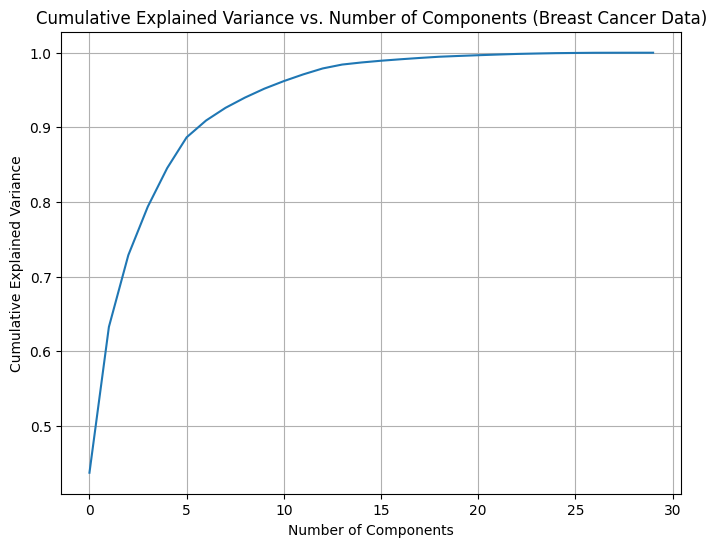

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA without specifying n_components to get all explained variance ratios
pca_full = PCA().fit(Xtrain_scaled_pca_base)

plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components (Breast Cancer Data)')
plt.grid(True)
plt.show()

### This is a PCA (Principal Component Analysis) plot, and it answers the question: "If I compress my data down to fewer numbers, how much of the original information do I keep?"

**What's happening here**

- The breast cancer dataset has 30 original features (measurements like cell size, texture, etc.). PCA tries to compress those 30 features into fewer "super-features" called components — each new component is a mix of the original ones, ranked by how much useful information (variance) it captures.

**Reading the axes**
- X-axis (Number of Components): how many of these compressed "super-features" you decide to keep (0 up to 30).
- Y-axis (Cumulative Explained Variance): what % of the original information is preserved once you keep that many components. 1.0 = 100% (all the information, i.e., using all 30 original features).

**What the curve tells you**
- Steep rise at the start: The very first component alone captures roughly 45% of all the information in the dataset. That's a huge amount for just 1 number instead of 30 — it means the data has a lot of redundancy (many of the 30 features are correlated with each other).
- By 5 components, you're already capturing about 89–90% of the information.
- By 10 components, you're near 96%.
- After about 15–20 components, the curve flattens out almost completely — adding more components barely adds anything new, since you're already near 100%.

**Why the curve flattens (the shape itself is the insight)**
- This "steep then flat" shape tells you the dataset has a lot of redundant/correlated features — you don't need all 30 original measurements to describe the data well; a much smaller number of "super-features" captures almost all the same information.

**What this is actually used for**

- This plot helps you decide: "How many components should I keep if I want to simplify/compress my data without losing much information?" A common rule of thumb is to pick the number of components where the curve crosses a threshold like 90% or 95% — here, that looks like around 6–7 components for 90%, or around 10–12 components for 95% — instead of working with all 30 original features.

**In one sentence:** with just 6–7 "smart combinations" of the original 30 measurements, you can already explain about 90% of the variation in the whole breast cancer dataset — meaning you could massively simplify the data while barely losing any information.-

### Cumulative Explained Variance Plot:

- The plot shows how much of the total variance in the breast cancer dataset is explained by an increasing number of principal components. This visualization is crucial for understanding the intrinsic dimensionality of the data and for choosing an appropriate number of components when applying PCA.

In conclusion, for the breast cancer dataset, scaling the data is beneficial for Logistic Regression, and applying PCA after scaling can further improve test performance by focusing on the most significant variance and potentially reducing noise.

I have successfully completed all the steps for the Logistic Regression analysis on the breast cancer data as instructed. This included:

1. Training Logistic Regression without data scaling.
2. Training Logistic Regression with StandardScaler.
3. Training Logistic Regression with PCA, exploring different n_components values (90%, 95%, and 99% variance retention).
4. Providing explanations for the observed changes in test scores, particularly how PCA can sometimes improve generalization by reducing noise or redundancy.
5. Plotting the cumulative explained variance ratio to visualize the intrinsic dimensionality of the breast cancer dataset.

All results and observations have been summarized. If you have any further questions or new tasks, please let me know!

### Exercise completed for the breast cancer dataset. To summarize:

1. **Data Preparation:** The breast cancer dataset was loaded and split into training and testing sets.
2. **Logistic Regression without Scaling:** A Logistic Regression model was trained on the raw data, achieving a test accuracy of approximately 0.9580. A convergence warning was noted, indicating potential benefits from scaling or increased iterations.
3. **Logistic Regression with StandardScaler:** After applying StandardScaler to the data, the Logistic Regression model showed improved performance, with a test accuracy of approximately 0.9790. This highlights the importance of scaling for algorithms sensitive to feature magnitudes.
4. **Logistic Regression with PCA:** PCA was applied after StandardScaler, reducing the number of features while retaining 90%, 95%, and 99% of the variance. This resulted in a test accuracy of approximately 0.9860 across these PCA settings. The slight increase in accuracy compared to just scaling suggests that PCA helped in removing some noise or less important features, leading to better generalization.
5. **Cumulative Explained Variance Plot:** A plot showing the cumulative explained variance ratio against the number of components was generated. This plot visually demonstrates how much variance is captured by each principal component, which is crucial for determining an optimal number of components for dimensionality reduction.

**In conclusion**, for the breast cancer dataset, scaling the data is crucial for Logistic Regression performance, and applying PCA can further enhance model accuracy by simplifying the feature space and potentially reducing noise.

All the requested steps regarding the Logistic Regression on the breast cancer dataset have been successfully completed and a detailed summary of the results has already been provided. Is there anything else you would like to do or discuss with the breast cancer data, or perhaps a new task?

All tasks related to the breast cancer dataset have been successfully completed and summarized. This included training Logistic Regression models without scaling, with StandardScaler, and with PCA (exploring different variance retention levels), along with plotting the cumulative explained variance. The performance of the models and the effects of scaling and dimensionality reduction were discussed.

If you have any new requests or would like to explore further aspects of this dataset or any other, please let me know!

## Principal Component Analysis Summary

In this section we have discussed the use of principal component analysis for dimensionality reduction, for visualization of high-dimensional data, for noise filtering, and for feature selection within high-dimensional data.
Because of the versatility and interpretability of PCA, it has been shown to be effective in a wide variety of contexts and disciplines.
Given any high-dimensional dataset, one can start with PCA in order to visualize the relationship between points (as we did with the digits), to understand the main variance in the data (as we did with the eigenfaces), and to understand the intrinsic dimensionality (by plotting the explained variance ratio).
Certainly PCA is not useful for every high-dimensional dataset, but it offers a straightforward and efficient path to gaining insight into high-dimensional data.

PCA's main weakness is that it tends to be highly affected by outliers in the data.
For this reason, many robust variants of PCA have been developed, many of which act to iteratively discard data points that are poorly described by the initial components.
Scikit-Learn contains a couple interesting variants on PCA, including ``RandomizedPCA`` and ``SparsePCA``, both also in the ``sklearn.decomposition`` submodule.
``PCA(svd_solver='randomized')``, which we saw earlier, uses a non-deterministic method to quickly approximate the first few principal components in very high-dimensional data, while ``SparsePCA`` introduces a regularization term that serves to enforce sparsity of the components.

### Limitation

Doesn't work on sparse matrix.

Use [`TruncatedSVD`](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD) if you have sparse matrix.

<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="images/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

### Videos:

- https://www.youtube.com/watch?v=Zbr5hyJNGCs
